# Heat indices

In [ ]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import xarray as xr
import xvec  # noqa: F401
from IPython.display import display
from meteora import climate_indices as meteora_ci
from meteora import utils as meteora_utils

from swiss_uhi_lcd import heat_warnings, plot_utils, stats_utils

sns.set_style("whitegrid")


def _read_lcd_ts_df(filepaths):
    ts_df = pd.concat(
        [
            pd.read_csv(filepath, index_col="time", parse_dates=["time"])
            for filepath in filepaths
        ],
        axis="columns",
    ).sort_index()
    return ts_df.loc[:, ~ts_df.columns.duplicated()]


def get_ts_df_dict(aws_ts_cube_filepath, lcd_ts_df_filepaths, cor_ts_df_filepaths):
    """Get a dictionary of time series data frames."""
    # AWS
    aws_ts_cube = xr.open_dataset(aws_ts_cube_filepath).xvec.decode_cf()
    aws_ts_df = (
        aws_ts_cube["temperature"]
        .set_index(geometry="station_id")
        .rename(geometry="station_id")
        .to_pandas()
    )

    # LCD (raw)
    lcd_ts_df = _read_lcd_ts_df(lcd_ts_df_filepaths)

    # LCD (corrected)
    cor_ts_df = _read_lcd_ts_df(cor_ts_df_filepaths)

    # put them all into a dict and return it
    return {"AWS": aws_ts_df, "LCD$_{raw}$": lcd_ts_df, "LCD$_{cor}$": cor_ts_df}

In [ ]:
agglom_data_dict = {
    "Bern": {
        "aws_ts_cube_filepath": "../data/interim/bern-aws-ts-cube.nc",
        "lcd_ts_df_filepaths": ["../data/interim/bern-lcd-ts-df.csv"],
        "lcd_stations_gdf_filepaths": ["../data/interim/bern-lcd-stations.gpkg"],
        "cor_ts_df_filepaths": ["../data/interim/bern-cor-ts-df.csv"],
    },
    "Lausanne": {
        "aws_ts_cube_filepath": "../data/interim/lausanne-aws-ts-cube.nc",
        "lcd_ts_df_filepaths": ["../data/interim/lausanne-lcd-ts-df.csv"],
        "lcd_stations_gdf_filepaths": ["../data/interim/lausanne-lcd-stations.gpkg"],
        "cor_ts_df_filepaths": ["../data/interim/lausanne-cor-ts-df.csv"],
    },
    "Neuchatel": {
        "aws_ts_cube_filepath": "../data/interim/neuchatel-aws-ts-cube.nc",
        "lcd_ts_df_filepaths": ["../data/interim/neuchatel-lcd-ts-df.csv"],
        "lcd_stations_gdf_filepaths": ["../data/interim/neuchatel-lcd-stations.gpkg"],
        "cor_ts_df_filepaths": ["../data/interim/neuchatel-cor-ts-df.csv"],
    },
    "Zurich (Decentlab)": {
        "aws_ts_cube_filepath": "../data/interim/zurich-aws-ts-cube.nc",
        "lcd_ts_df_filepaths": ["../data/interim/zurich-awel-lcd-ts-df.csv"],
        "lcd_stations_gdf_filepaths": ["../data/interim/zurich-awel-lcd-stations.gpkg"],
        "cor_ts_df_filepaths": ["../data/interim/zurich-awel-cor-ts-df.csv"],
    },
    "Zurich (Barani)": {
        "aws_ts_cube_filepath": "../data/interim/zurich-aws-ts-cube.nc",
        "lcd_ts_df_filepaths": ["../data/interim/zurich-ugz-lcd-ts-df.csv"],
        "lcd_stations_gdf_filepaths": ["../data/interim/zurich-ugz-lcd-stations.gpkg"],
        "cor_ts_df_filepaths": ["../data/interim/zurich-ugz-cor-ts-df.csv"],
    },
}
agglom_names = list(agglom_data_dict.keys())

min_valid_frac = 0.8

col_wrap = 3

dst_fig_heat_warnings_barplot_filepath = (
    "../reports/figures/heat-warnings-barplot-separate.pdf"
)
dst_fig_tn_barplot_filepath = "../reports/figures/tn-barplot-separate.pdf"
dst_fig_tn_station_maps_filepath = "../reports/figures/tn-station-maps-separate.png"
dst_fig_t_diurnal_cycle_filepath = "../reports/figures/t-diurnal-cycle-separate.pdf"
dst_fig_t_station_type_maps_filepath = (
    "../reports/figures/t-station-type-maps-separate.png"
)
savefig_kwargs = {"dpi": 300, "bbox_inches": "tight"}

In [ ]:
# load stations locations
aws_gdf = pd.concat(
    [
        xr.open_dataset(agglom_data["aws_ts_cube_filepath"])
        .xvec.decode_cf()["station_id"]
        .xvec.to_geopandas()
        for agglom_data in agglom_data_dict.values()
    ]
)
lcd_gdf = pd.concat(
    [
        gpd.read_file(lcd_stations_gdf_filepath)
        for agglom_data in agglom_data_dict.values()
        for lcd_stations_gdf_filepath in agglom_data["lcd_stations_gdf_filepaths"]
    ]
)
# exclude stations with less than min_valid_frac non-NaN data
lcd_ts_df = _read_lcd_ts_df(
    [
        filepath
        for agglom_data in agglom_data_dict.values()
        for filepath in agglom_data["lcd_ts_df_filepaths"]
    ]
)
valid_frac = lcd_ts_df.notna().mean()
lcd_low_valid_ids = valid_frac[valid_frac < min_valid_frac].index.tolist()
# exclude:
# - AWS Kloten (Zurich) because it makes the maps too high and narrow
# - LCD sensor J4 (Zurich)
aws_exclude_ids = ["KLO"]
aws_gdf = aws_gdf[~aws_gdf["station_id"].isin(aws_exclude_ids)]
lcd_exclude_ids = lcd_low_valid_ids  #  + ["J4"]
lcd_gdf = lcd_gdf[~lcd_gdf["station_id"].isin(lcd_exclude_ids)]
stations_gser = pd.concat(
    [
        _stations_gdf.set_index("station_id")["geometry"]
        for _stations_gdf in [aws_gdf, lcd_gdf]
    ]
)
# drop duplicated zurich AWS
stations_gser = stations_gser.drop_duplicates(keep="first")

In [ ]:
# summary table: number of valid LCD stations per city/network (after exclusions)
valid_lcd_ids = set(lcd_gdf["station_id"])
summary_rows = []
for agglom_name, agglom_data in agglom_data_dict.items():
    n_valid = sum(
        gpd.read_file(fp)["station_id"].isin(valid_lcd_ids).sum()
        for fp in agglom_data["lcd_stations_gdf_filepaths"]
    )
    summary_rows.append({"City/Network": agglom_name, "N. valid LCD stations": n_valid})
display(pd.DataFrame(summary_rows))

,City/Network,N. valid LCD stations
0,Bern,77
1,Lausanne,7
2,Neuchatel,28
3,Zurich (Decentlab),25
4,Zurich (Barani),83


In [ ]:
ts_df_dict = {
    agglom_name: get_ts_df_dict(
        agglom_data["aws_ts_cube_filepath"],
        agglom_data["lcd_ts_df_filepaths"],
        agglom_data["cor_ts_df_filepaths"],
    )
    for agglom_name, agglom_data in agglom_data_dict.items()
}

## Tropical nights

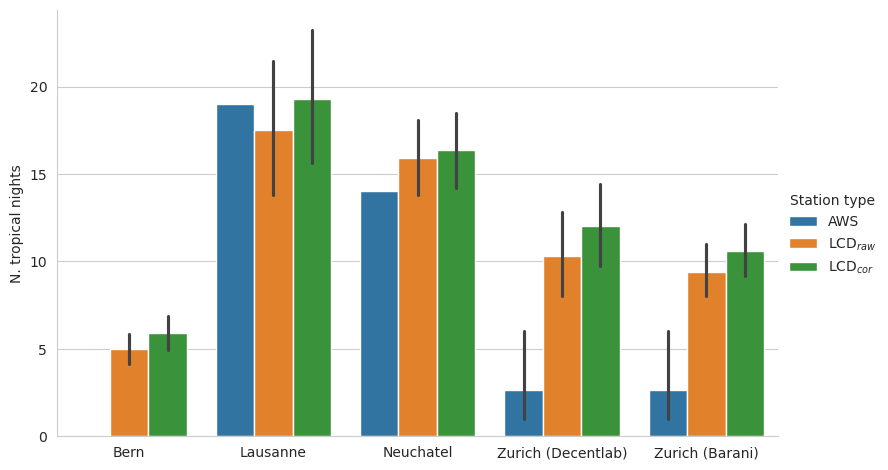

In [ ]:
# tropical nights (tn_days_above) summed across all years
tn_records = []
for agglom_name, station_type_dict in ts_df_dict.items():
    for station_type, ts_df in station_type_dict.items():
        long_ts_df = (
            ts_df.rename_axis("time")
            .rename_axis(columns="station_id")
            .stack()
            .rename("temperature")
            .reset_index()
            .set_index(["station_id", "time"])
        )
        tn_df = meteora_ci.tn_days_above(long_ts_df)
        tn_total_ser = tn_df.sum(axis="index", min_count=1).rename("N. tropical nights")
        tn_records.append(
            tn_total_ser.reset_index().assign(
                **{"Station type": station_type, "agglom_name": agglom_name}
            )
        )
tn_days_df = pd.concat(tn_records, ignore_index=True)

tn_bar_kwargs = dict(
    x="agglom_name",
    y="N. tropical nights",
    hue="Station type",
    errorbar=("ci", 95),
    n_boot=1000,
    seed=42,
)

g = sns.catplot(
    tn_days_df,
    kind="bar",
    **tn_bar_kwargs,
    aspect=1.6,
)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_xlabels(label="")
g.figure.savefig(dst_fig_tn_barplot_filepath, **savefig_kwargs)

### Tropical nights bar values (mean and 95% CI)


In [ ]:
tn_bar_table_df = stats_utils.barplot_summary(tn_days_df, **tn_bar_kwargs)
display(tn_bar_table_df.round(4))

,agglom_name,Station type,Mean N. tropical nights,CI low,CI high,N
0,Bern,AWS,0.0000,0.0000,0.0000,1
1,Bern,LCD$_{cor}$,5.9167,4.9762,6.9167,84
2,Bern,LCD$_{raw}$,4.9643,4.1664,5.8929,84
3,Lausanne,AWS,19.0000,19.0000,19.0000,1
4,Lausanne,LCD$_{cor}$,19.3077,15.6154,23.0019,13
5,Lausanne,LCD$_{raw}$,17.5385,13.7692,21.3077,13
6,Neuchatel,AWS,14.0000,14.0000,14.0000,1
7,Neuchatel,LCD$_{cor}$,16.3571,13.7500,18.3937,28
8,Neuchatel,LCD$_{raw}$,15.9286,13.3920,17.9295,28
9,Zurich (Barani),AWS,2.6667,1.0000,6.0000,3


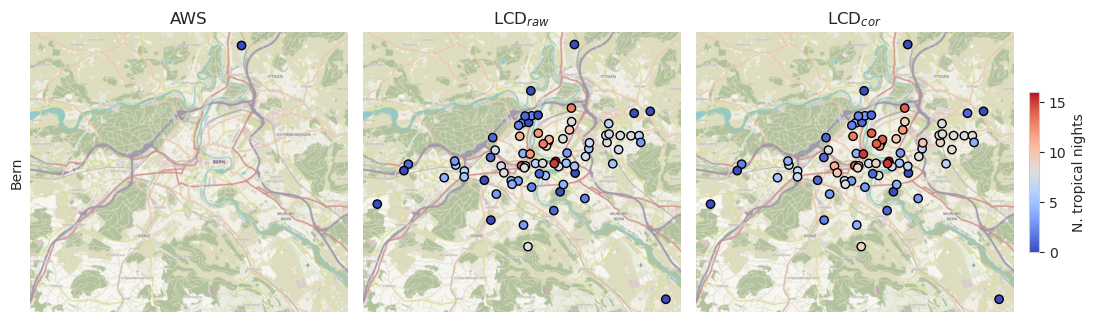

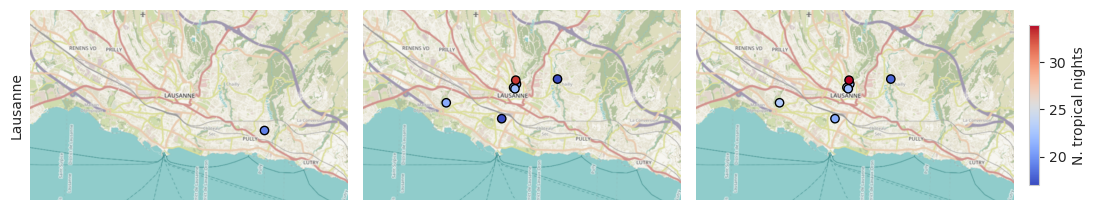

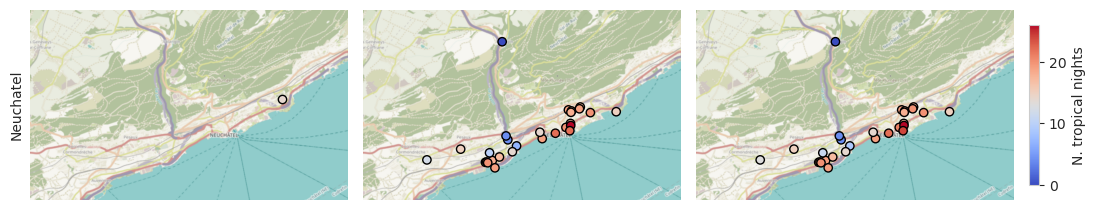

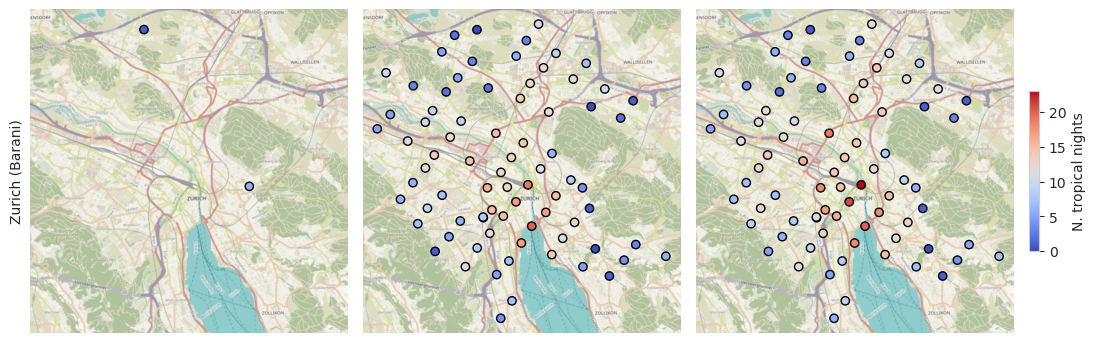

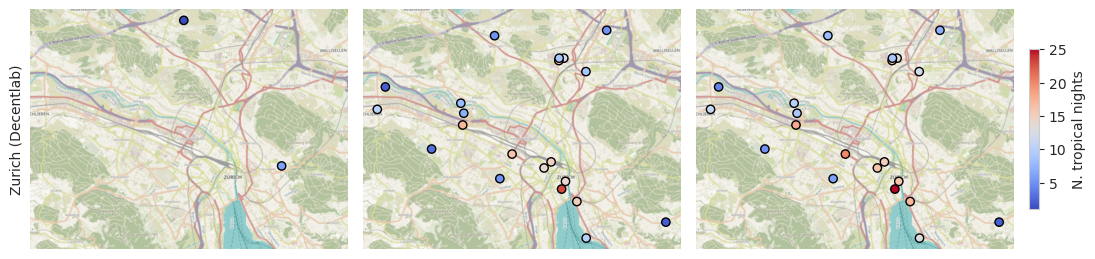

In [ ]:
value_name = "N. tropical nights"
tn_plot_gdfs = []
vmin_dict = {}
vmax_dict = {}
for agglom_name, agglom_df in tn_days_df.groupby("agglom_name"):
    _agglom_plot_gdf = gpd.GeoDataFrame(
        agglom_df,
        geometry=agglom_df["station_id"].map(stations_gser),
        crs=stations_gser.crs,
    )
    _agglom_plot_gdf = _agglom_plot_gdf.dropna(subset=[value_name, "geometry"])
    vmin_dict[agglom_name] = _agglom_plot_gdf[value_name].min()
    vmax_dict[agglom_name] = _agglom_plot_gdf[value_name].max()
    tn_plot_gdfs.append(_agglom_plot_gdf.assign(**{"agglom_name": agglom_name}))
tn_plot_gdf = pd.concat(tn_plot_gdfs)

figs = plot_utils.plot_station_map_grid_separate(
    tn_plot_gdf,
    value_col=value_name,
    vmin_dict=vmin_dict,
    vmax_dict=vmax_dict,
    cmap="coolwarm",
    value_label=value_name,
)
for agglom_name, fig in figs.items():
    dst_filepath = dst_fig_tn_station_maps_filepath.replace(
        ".png",
        f"-{agglom_name.lower().replace(' ', '-').replace('(', '').replace(')', '')}"
        ".png",
    )
    fig.savefig(dst_filepath, **savefig_kwargs)

## Heat warnings

In [ ]:
heat_days_dfs = []
level_kwargs_dict = {
    "Level 4": heat_warnings.LEVEL_4_KWARGS,
    "Level 3": heat_warnings.LEVEL_3_KWARGS,
    "Level 2": heat_warnings.LEVEL_2_KWARGS,
}


def _days_in_hot_spell_runs(hot_day_ser, min_run_len):
    hot_day_ser = hot_day_ser.fillna(False)
    if min_run_len <= 1:
        return hot_day_ser
    run_id = (~hot_day_ser).cumsum()
    run_len = hot_day_ser.groupby(run_id).transform("sum")
    return hot_day_ser & run_len.ge(min_run_len)


for agglom_name, _ts_df_dict in ts_df_dict.items():
    for station_type, ts_df in _ts_df_dict.items():
        daily_tmean_df = ts_df.resample("D").mean().rename_axis(columns="station_id")
        for level, level_kwargs in level_kwargs_dict.items():
            thresh = level_kwargs["heatwave_t_threshold"]
            window = level_kwargs["heatwave_n_consecutive_days"]

            # Level 2: all days above threshold.
            # Levels 3/4: only days that belong to runs >= window days.
            hot_day_mask_df = daily_tmean_df.gt(thresh)
            hot_day_mask_df = hot_day_mask_df.apply(
                _days_in_hot_spell_runs,
                min_run_len=window,
            )

            annual_hot_days_df = (
                hot_day_mask_df.astype(float)
                .groupby(hot_day_mask_df.index.year)
                .sum(min_count=1)
            )
            annual_hot_days_df.index.name = "time"

            _heat_df = (
                annual_hot_days_df.reset_index()
                .melt(
                    id_vars="time",
                    var_name="station_id",
                    value_name="N. days",
                )
                .assign(
                    **{
                        "level": level,
                        "Station type": station_type,
                        "agglom_name": agglom_name,
                    }
                )
            )
            heat_days_dfs.append(_heat_df)
heat_days_df = pd.concat(heat_days_dfs, ignore_index=True).dropna(subset=["N. days"])

# common kwargs for both the catplot (barplot) and its summary
heat_bar_kwargs = dict(
    x="level",
    y="N. days",
    hue="Station type",
    col="agglom_name",
    errorbar=("ci", 95),
    n_boot=1000,
    seed=42,
)

g = sns.catplot(
    heat_days_df,
    kind="bar",
    **heat_bar_kwargs,
    col_wrap=col_wrap,
)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_xlabels(label="")
g.figure.savefig(dst_fig_heat_warnings_barplot_filepath, **savefig_kwargs)

In [ ]:
heat_bar_table_df = stats_utils.barplot_summary(heat_days_df, **heat_bar_kwargs)
display(heat_bar_table_df.round(4))

,agglom_name,level,Station type,Mean N. days,CI low,CI high,N
0,Bern,Level 2,AWS,3.0000,3.0000,3.0000,1
1,Bern,Level 2,LCD$_{cor}$,11.6429,10.4643,12.6789,84
2,Bern,Level 2,LCD$_{raw}$,13.5238,12.3452,14.5833,84
3,Bern,Level 3,AWS,3.0000,3.0000,3.0000,1
4,Bern,Level 3,LCD$_{cor}$,7.8333,6.9759,8.5958,84
5,Bern,Level 3,LCD$_{raw}$,8.9405,7.9405,9.8929,84
6,Bern,Level 4,AWS,0.0000,0.0000,0.0000,1
7,Bern,Level 4,LCD$_{cor}$,0.7619,0.4643,1.1071,84
8,Bern,Level 4,LCD$_{raw}$,1.5833,1.2024,2.0119,84
9,Lausanne,Level 2,AWS,16.0000,16.0000,16.0000,1


In [ ]:
# hot day periods per agglomeration (daily mean > 25°C based on corrected LCD)
hot_threshold = 25
ref_station_type = "LCD$_{cor}$"
hot_periods_dict = {}
for agglom_name, _ts_df_dict in ts_df_dict.items():
    ref_ts_df = _ts_df_dict[ref_station_type]
    hot_periods = []
    for year, year_ts_df in ref_ts_df.groupby(ref_ts_df.index.year):
        hot_periods.extend(
            heat_warnings.get_heatwave_periods(
                year_ts_df,
                heatwave_t_threshold=hot_threshold,
                heatwave_n_consecutive_days=1,
            )
        )
    hot_periods_dict[agglom_name] = hot_periods

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_205515/2241633714.py:1: SyntaxWarning: invalid escape sequence '\c'
  value_name = "T$^{\circ}$ [C]"


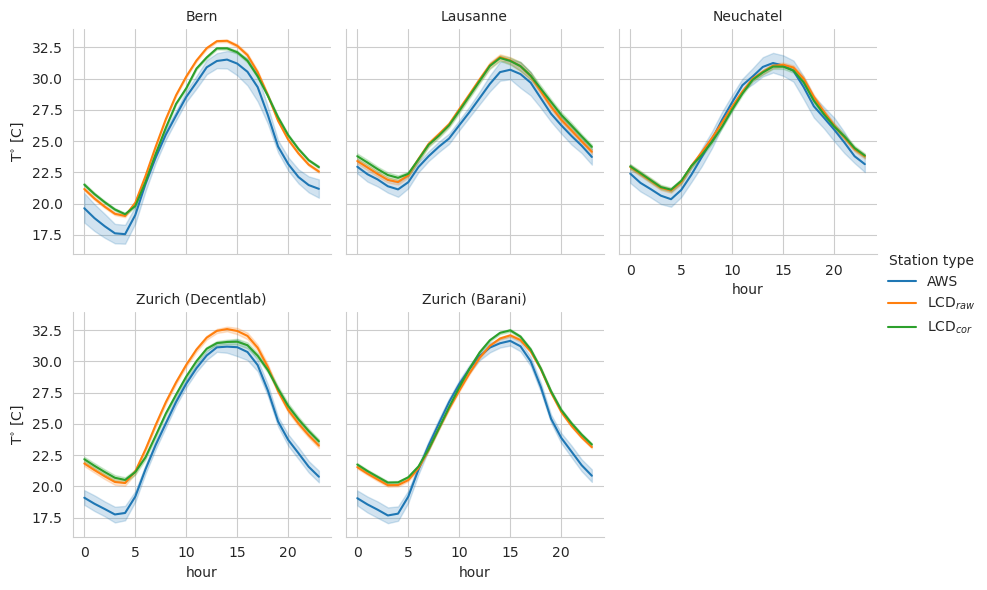

In [ ]:
value_name = "T$^{\circ}$ [C]"
var_name = "Station type"

plot_df = pd.concat(
    [
        pd.concat(
            [
                meteora_utils.get_heatwave_ts_df(
                    ts_df,
                    heatwave_periods=hot_periods_dict[agglom_name],
                )
                .rename_axis(columns="station_id")
                .stack()
                .rename(station_type)
                for station_type, ts_df in ts_df_dict[agglom_name].items()
            ],
            axis="columns",
        )
        .reset_index()
        .melt(
            id_vars=["heatwave", "time", "station_id"],
            var_name=var_name,
            value_name=value_name,
        )
        .assign(**{"agglom_name": agglom_name})
        for agglom_name in ts_df_dict
    ]
).dropna()
plot_df = plot_df.assign(**{"hour": plot_df["time"].dt.hour})
g = sns.FacetGrid(plot_df, col="agglom_name", hue=var_name, col_wrap=col_wrap)
g.map(sns.lineplot, "hour", value_name)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend()
g.figure.savefig(dst_fig_t_diurnal_cycle_filepath, **savefig_kwargs)